In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc, accuracy_score, confusion_matrix, classification_report, auc, precision_recall_curve
from imblearn.over_sampling import SMOTE
import seaborn as sns
from sklearn.linear_model import LogisticRegression


In [28]:
url = r"D:\Sem_4\Supervised Machine Learning lab (SMLL)\8\Practice dataset Social_Network_Ads.csv"
df = pd.read_csv(url)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [29]:
# Display basic information about the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.\n")
print(f"The dataset has {df.isnull().sum().sum()} missing values.\n")
print(f"The dataset has {df.duplicated().sum()} duplicated rows.\n")
print(f"The dataset has columns\n", df.columns)
print(f"The dataset has description\n", df.describe())


The dataset has 400 rows and 5 columns.

The dataset has 0 missing values.

The dataset has 0 duplicated rows.

The dataset has columns
 Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')
The dataset has description
             User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [30]:

# Encoding categorical data
label_encoder = LabelEncoder()
df["Gender"] = label_encoder.fit_transform(df["Gender"])

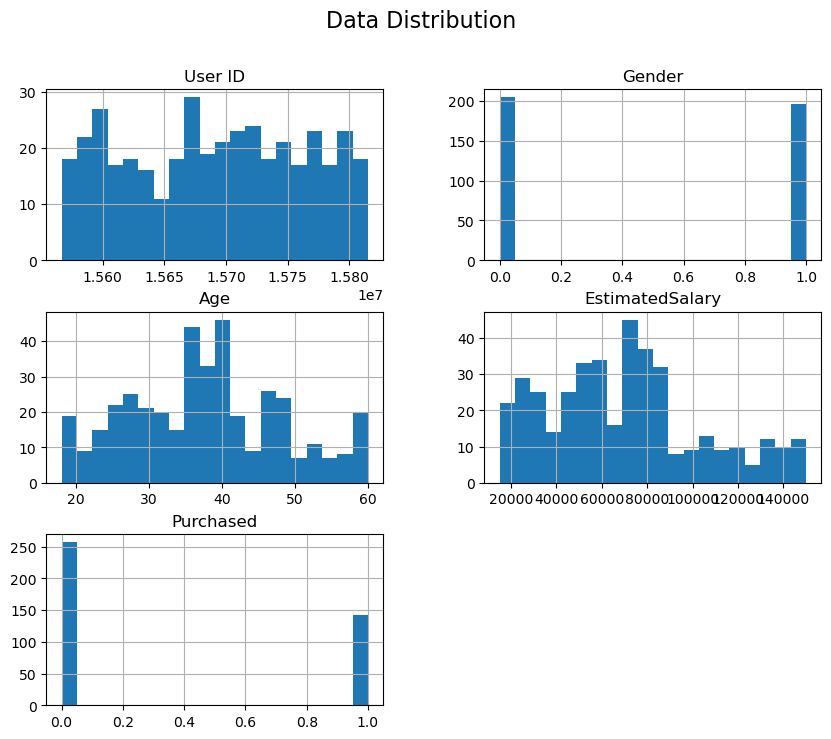

In [31]:
# Data Distribution
plt.Figure(figsize=(10, 5))
df.hist(figsize=(10, 8), bins=20)
plt.suptitle("Data Distribution", fontsize=16)
plt.show()

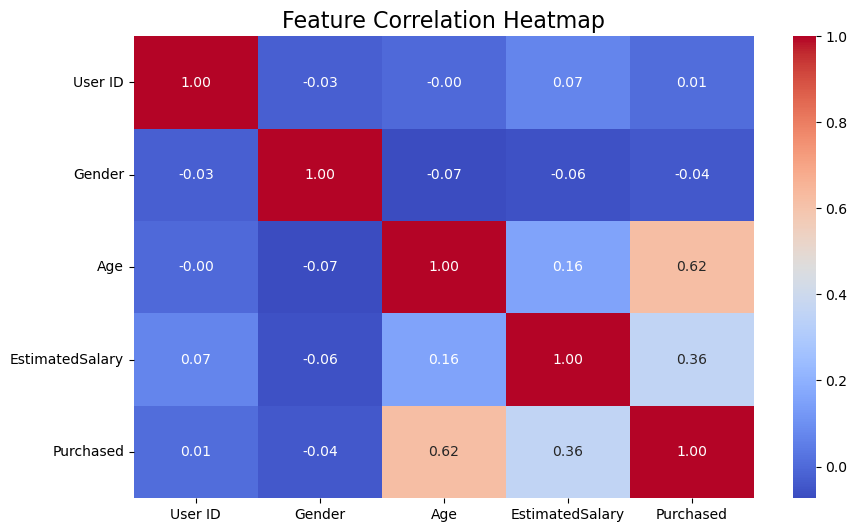

In [32]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

In [33]:
# Splitting Data into Features and Target
X = df.drop("Purchased", axis=1)
y = df["Purchased"]
print(X.shape, y.shape)

(400, 4) (400,)


In [34]:
# Splitting Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [36]:
# Model Training - Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

In [37]:
# Model Prediction
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [38]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC Score:", roc_auc)
print("classification_report:\n", classification_report(y_test, y_pred))
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8125
F1 Score: 0.7058823529411765
Precision: 0.8181818181818182
Recall: 0.6206896551724138
ROC AUC Score: 0.9066937119675457
classification_report:
               precision    recall  f1-score   support

           0       0.81      0.92      0.86        51
           1       0.82      0.62      0.71        29

    accuracy                           0.81        80
   macro avg       0.81      0.77      0.78        80
weighted avg       0.81      0.81      0.81        80

confusion_matrix:
 [[47  4]
 [11 18]]


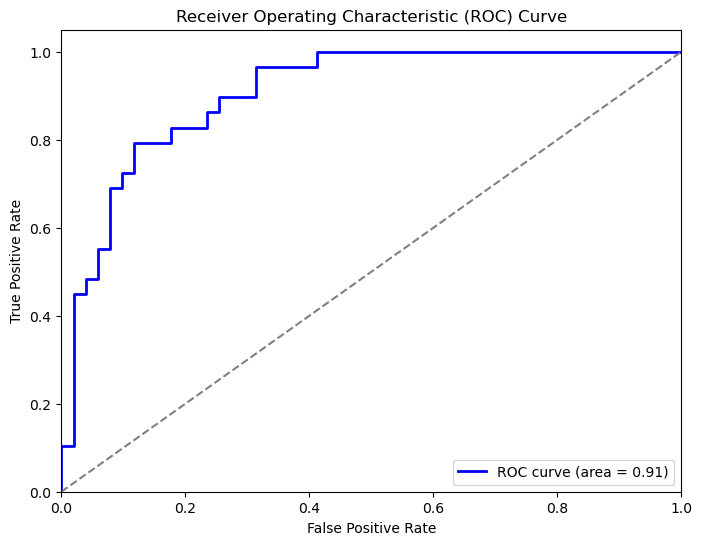

In [39]:
# ROC - AUC curve
fpr,tpr,_ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()